<a href="https://colab.research.google.com/github/Visionary-DataWorks/DSPL-Project/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#Import Functions
import pandas as pd

In [34]:
#Load the preprocessed dataset
data=pd.read_csv('/content/cleaned_train_data.csv')

In [35]:
#print head
data.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_category,city_encoded
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4,11
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1,13
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4,19
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4,19
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4,11


In [36]:
print(data.columns)

Index(['Customer_ID', 'outlet_city', 'luxury_sales', 'fresh_sales',
       'dry_sales', 'cluster_category', 'city_encoded'],
      dtype='object')


In [37]:
# Define input features and target variable
X = data[['luxury_sales', 'fresh_sales','dry_sales', 'city_encoded']]
Y = data['cluster_category']


In [38]:
#scale input variables
from sklearn.preprocessing import StandardScaler, MinMaxScaler

std_scaler = StandardScaler()
X1 = std_scaler.fit_transform(X)

minmax_scaler = MinMaxScaler()
X2 = minmax_scaler.fit_transform(X)

In [39]:
# Train_test_split
from sklearn.model_selection import train_test_split
X1_train, X1_test, Y_train, Y_test = train_test_split(X1,Y, test_size=0.2, random_state=42,stratify=Y)
X2_train, X2_test, Y_train, Y_test = train_test_split(X2,Y, test_size=0.2, random_state=42,stratify=Y)

In [40]:
#check shape for whole dataset
print('Whole Data shape', data.shape)

Whole Data shape (774148, 7)


In [41]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(multi_class='ovr')
logreg.fit(X1_train, Y_train)
y_pred=logreg.predict(X1_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [42]:
#To see the predicted values
print("Predicted Values: ", y_pred)

Predicted Values:  [5 4 4 ... 4 3 1]


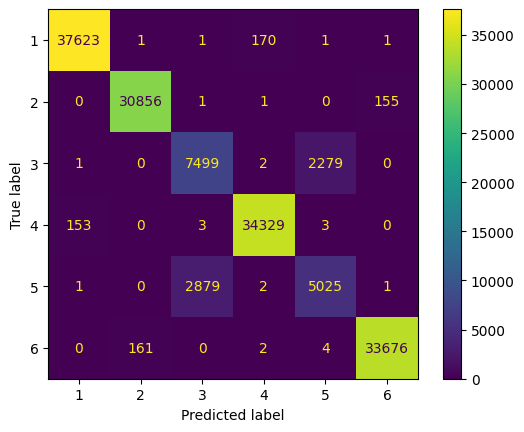

In [43]:
# plot of the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

confusion_m = confusion_matrix(Y_test, y_pred, labels=logreg.classes_)

# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_m,display_labels=logreg.classes_)
disp.plot()

In [44]:
# Import the function calculate accuracy score
from sklearn.metrics import accuracy_score
# Apply the function to find the correct predictions
accuracy = accuracy_score(Y_test,y_pred)
# Display the accuracy
print ('The Logistic Regression Model Accuracy:',accuracy)

The Logistic Regression Model Accuracy: 0.9623974681909191


In [45]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37797
           2       0.99      0.99      0.99     31013
           3       0.72      0.77      0.74      9781
           4       0.99      1.00      1.00     34488
           5       0.69      0.64      0.66      7908
           6       1.00      1.00      1.00     33843

    accuracy                           0.96    154830
   macro avg       0.90      0.90      0.90    154830
weighted avg       0.96      0.96      0.96    154830

